In [1]:
#Quelle: https://github.com/Samaretas/ITTI-saliency-detection
#lade libaries und Funktionen
import numpy as np
import cv2

def get_intensity(image):
    """
        Get intensity map. Values range from 0 to 1.
    """
    # convert scale of array elements
    src = np.float32(image) * 1./255
    # extract intensity
    intensity_map = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)
    return intensity_map


def get_gaussian_pyramid(image):
    """
        Get gaussian pyramid with 8 levels of downsampling.
    """
    pyr = list()
    pyr.append(image)
    for i in range(1, 9):
        next_layer = cv2.pyrDown(pyr[i-1])
        pyr.append(next_layer)
    return pyr


def center_surround_diff(gauss_pyr):
    maps = list()
    for c in range(2, 5):
        center = gauss_pyr[c]
        size = (center.shape[1], center.shape[0])
        for s in range(3, 5):
            surround = cv2.resize(
                gauss_pyr[c+s], size, interpolation=cv2.INTER_LINEAR)
            cs_difference_map = cv2.absdiff(center, surround)
            maps.append(cs_difference_map)
    return maps


def simple_normalization(image, M=1):
    img_min, img_max, _, _ = cv2.minMaxLoc(image)
    if img_min != img_max:
        normalized = image/(img_max-img_min) - img_min/(img_max-img_min)
        if M != 1:
            normalized = normalized*M
    else:
        normalized = image - img_min
    return normalized


def compute_average_local_maxima(feature_map, stepsize=-1):
    # NOTE: I compute local maxima taking into account last slices of the matrix
    # 30 corresponds to ~1 degree of visual angle
    local_avg_size = 30
    width = feature_map.shape[1]
    height = feature_map.shape[0]
    avg_size = local_avg_size if (stepsize < 1) else stepsize
    if(avg_size > height-1):
        avg_size = height-1
    if(avg_size > width-1):
        avg_size = width-1
    # find local maxima
    num_maxima = 0
    sum_all_maxima = 0

    for y in range(0, height-avg_size, avg_size):
        for x in range(0, width-avg_size, avg_size):
            local_img = feature_map[y:y+avg_size, x:x+avg_size]
            _, loc_max, _, _ = cv2.minMaxLoc(local_img)
            sum_all_maxima += loc_max
            num_maxima += 1
            last_x = x+avg_size
        local_img = feature_map[y:y+avg_size, last_x:(width)]
        _, loc_max, _, _ = cv2.minMaxLoc(local_img)
        sum_all_maxima += loc_max
        num_maxima += 1
        last_y = y+avg_size

    for x in range(0, width-avg_size, avg_size):
        local_img = feature_map[last_y:height, x:x+avg_size]
        _, loc_max, _, _ = cv2.minMaxLoc(local_img)
        sum_all_maxima += loc_max
        num_maxima += 1
        last_x = x+avg_size
    local_img = feature_map[last_y:height, last_x:(width)]
    _, loc_max, _, _ = cv2.minMaxLoc(local_img)
    sum_all_maxima += loc_max
    num_maxima += 1

    # averaging over all the local regions
    return sum_all_maxima / num_maxima


def normalize_map(feature_map):
    """
        This function implements the particular normalization operator N
        described in Itti 1998.
    """
    # normalize in range [0...M], choice M=1
    M = 1
    simply_normalized = simple_normalization(feature_map, M)
    # get average local maximum
    avg_local_maximum = compute_average_local_maxima(
        simply_normalized)
    # normalize feature map as from paper
    coeff_normalization = (M-avg_local_maximum)**2
    itti_normalized = simply_normalized * coeff_normalization
    return itti_normalized

# INTENSITY
def get_intensity_conspicuity_map(intensity):
    shape = intensity.shape
    # get Gaussian pyramid for intensity
    intensity_gauss_pyr = get_gaussian_pyramid(intensity)
    # compute 6 feature maps at different scales
    feature_maps = center_surround_diff(intensity_gauss_pyr)
    # normalize feature maps
    norm_feature_maps = [normalize_map(m) for m in feature_maps]
    # get conspicuity map from normalized maps

    # NOTE: in 1998 paper they use scale 4 for the conspicuity maps, here I use scale 0
    norm_feature_maps = [
        cv2.resize(m, shape[::-1],
                   interpolation=cv2.INTER_LINEAR)
        for m in norm_feature_maps]

    # sum all c-s diff maps into conspicuity map
    intensity_conspicuity = np.zeros_like(intensity)
    for cs_index in range(6):
        intensity_conspicuity += norm_feature_maps[cs_index]

    return normalize_map(intensity_conspicuity)

# COLOR
def get_color_conspicuity_map(image):
    """
        The slower between the maps, may be further optimized.
    """
    # get color channels
    (b, g, r) = get_color_channels(image)
    shape = b.shape

    # build 4 broadly-tuned color channels
    R_ch = (r-(g+b))/2
    G_ch = (g-(r+b))/2
    B_ch = (b-(r+g))/2
    Y_ch = ((r+g)/2 - abs(r-g)/2 - b)

    # set to 0 negative values
    R_ch[R_ch < 0] = 0
    G_ch[G_ch < 0] = 0
    B_ch[B_ch < 0] = 0
    Y_ch[Y_ch < 0] = 0

    # create gaussian pyramids
    red_gauss_pyr = get_gaussian_pyramid(R_ch)
    green_gauss_pyr = get_gaussian_pyramid(G_ch)
    blue_gauss_pyr = get_gaussian_pyramid(B_ch)
    yellow_gauss_pyr = get_gaussian_pyramid(Y_ch)

    # get feature maps for different color spaces
    rg_color_space_maps = get_color_space_feature_maps(
        red_gauss_pyr, green_gauss_pyr)
    by_color_space_maps = get_color_space_feature_maps(
        blue_gauss_pyr, yellow_gauss_pyr)

    # normalize feature maps
    rg_color_space_maps = [normalize_map(
        m) for m in rg_color_space_maps]
    by_color_space_maps = [normalize_map(
        m) for m in by_color_space_maps]

    # get conspicuity map
    color_conspicuity_map = get_conspicuity_from_color_spaces(
        rg_color_space_maps, by_color_space_maps, shape)
    return normalize_map(color_conspicuity_map)


def get_color_channels(image):
    intensity = np.float32(np.sum(image, axis=2))
    _, max_int, _, _ = cv2.minMaxLoc(intensity)
    min_intensity_admitted = max_int/10

    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            if intensity[y][x] < min_intensity_admitted:
                image[y][x] = [0, 0, 0]

    src = np.zeros_like(image, dtype=np.float32)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            if image[y][x].any() > 0:
                src[y][x] = np.float32(np.float32(
                    image[y][x])/np.float32(max_int))
    return cv2.split(src)


def get_color_space_feature_maps(c1_pyr, c2_pyr):
    # here we compute the feature maps for the double opponent color system
    feature_maps = list()
    for c in range(2, 5):
        center = c1_pyr[c]-c2_pyr[c]
        size = (center.shape[1], center.shape[0])
        for s in range(3, 5):
            surround = c2_pyr[c+s] - c1_pyr[c+s]
            res_surround = center - \
                cv2.resize(surround, size, interpolation=cv2.INTER_LINEAR)
            cs_diff = cv2.absdiff(center, res_surround)
            feature_maps.append(cs_diff)
    return feature_maps


def get_conspicuity_from_color_spaces(rg_space, by_space, shape):
    conspicuity_map = np.zeros(shape)
    # resizing normalized feature maps
    # NOTE: in 1998 paper they use scale 4 for the conspicuity maps, here I use scale 0
    rg_space = [cv2.resize(m, shape[::-1],
                           interpolation=cv2.INTER_LINEAR) for m in rg_space]
    by_space = [cv2.resize(m, shape[::-1],
                           interpolation=cv2.INTER_LINEAR) for m in by_space]
    for cs_index in range(6):
        conspicuity_map += (rg_space[cs_index] + by_space[cs_index])
    return conspicuity_map

# ORIENTATION
def get_gabor_kernels(shape):
    # NOTE: Gabor Kernels are chosen by a trial-end-error mean
    kernel_list = list()
    kernel_size = int(min(shape)/42)
    lamb = kernel_size
    sigma = lamb*.56
    gamma = 0.5
    psi = 0
    orientations = [0, (np.pi/4), (np.pi/2), (np.pi*3/4)]

    for theta in orientations:
        gabor_kernel = cv2.getGaborKernel(
            (kernel_size, kernel_size), sigma, theta, lamb, gamma, psi, ktype=cv2.CV_32F)
        gabor_kernel = gabor_kernel/gabor_kernel.sum()
        kernel_list.append(gabor_kernel)

    return kernel_list


def get_conspicuity_from_orienation_feature_maps(orient_feature_maps, shape, debug=False):
    conspicuity_map = np.zeros(shape)
    i = 0
    for orientation in orient_feature_maps:
        i += 1
        orientation_conspicuity = np.zeros(shape)
        for feature_map in orientation:
            normalized = normalize_map(feature_map)
            resized = cv2.resize(
                normalized, shape[::-1], interpolation=cv2.INTER_LINEAR)
            orientation_conspicuity += resized
        if(debug):
            cv2.imshow(f'Orientation {i}', orientation_conspicuity)
            cv2.waitKey(0)
        conspicuity_map += normalize_map(orientation_conspicuity)
    return conspicuity_map


def get_orientation_conspicuity_map(intensity, debug=False):
    shape = intensity.shape
    # get gabor filters
    filters = get_gabor_kernels(shape)
    # convolve intensity, obtain 4 preferred orientations
    oriented_intensities = [
        cv2.filter2D(intensity, cv2.CV_32F, kernel) for kernel in filters
    ]

    for i in range(len(oriented_intensities)):
        intensity = oriented_intensities[i]
        kernel = filters[i]
        if(debug):
            cv2.imshow(f'Intensity {i}', intensity)
            cv2.imshow(f'Kernel {i}', kernel)
    if(debug):
        cv2.waitKey(0)

    # get a gaussian pyramid for each orientation
    intensity_pyramids = [
        get_gaussian_pyramid(oriented_intensity) for oriented_intensity in oriented_intensities
    ]
    # get center surround differences
    cs_differences = [
        center_surround_diff(oriented_pyr) for oriented_pyr in intensity_pyramids
    ]
    # compute conspicuity map for orientation
    orientation_conspicuity_map = get_conspicuity_from_orienation_feature_maps(
        cs_differences, shape, debug)
    return normalize_map(orientation_conspicuity_map)

# COMPLETE
def get_spatial_saliency_map(image):
    intensity = get_intensity(image)
    intensity_conspicuity = get_intensity_conspicuity_map(intensity)
    color_conspicuity = get_color_conspicuity_map(image)
    orientation_conspicuity = get_orientation_conspicuity_map(intensity)

    n_intensity = normalize_map(intensity_conspicuity)
    c_intensity = normalize_map(color_conspicuity)
    o_intensity = normalize_map(orientation_conspicuity)
    saliency_map = (n_intensity+c_intensity+o_intensity)*(1/3)

    return saliency_map, n_intensity, c_intensity, o_intensity

In [9]:
import os
import cv2
#from scipy.io import savemat

image = cv2.imread(r'C:\Users\Diana\Desktop\OSIE40\1001.jpg')
saliency_map, intensity_intensity, color_intensity, orientation_intensity = get_spatial_saliency_map(image)
saliency_map_norm = cv2.normalize(saliency_map, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
color_map_norm = cv2.normalize(color_intensity, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
orientation_map_norm = cv2.normalize(orientation_intensity, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
intensity_map_norm = cv2.normalize(intensity_intensity, None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)

#savemat('saliency_map.mat', {'saliency_map': saliency_map_norm})

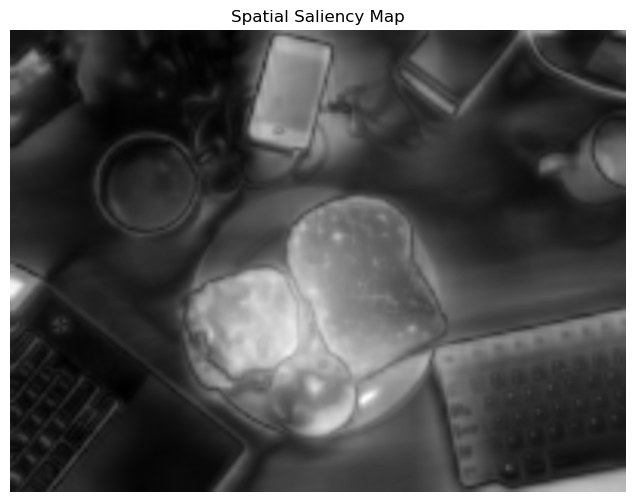

In [13]:
import matplotlib.pyplot as plt
# Assuming saliency_map is already computed
plt.figure(figsize=(8, 6))
plt.imshow(saliency_map_norm, cmap='gray')  # 'gray' colormap for better contrast
plt.title("Spatial Saliency Map")
plt.axis('off')  # Hide axes
plt.show()

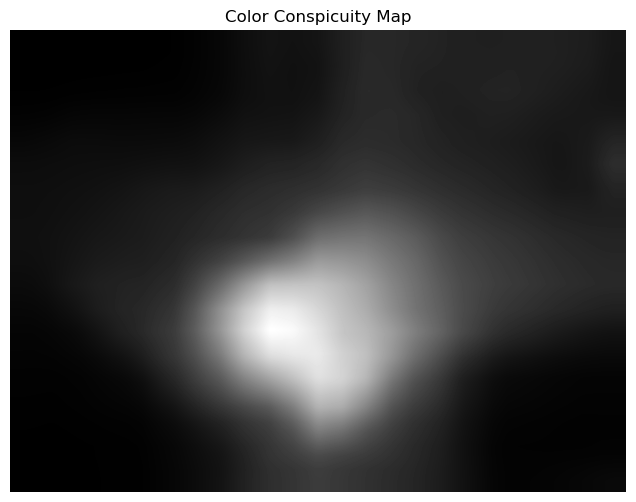

In [19]:
plt.figure(figsize=(8, 6))
plt.imshow(color_map_norm, cmap='gray')  # 'gray' colormap for better contrast
plt.title("Color Conspicuity Map")
plt.axis('off')  # Hide axes
plt.show()

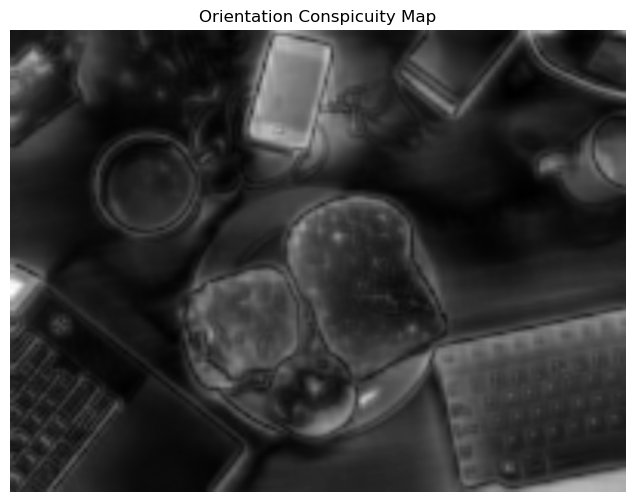

In [21]:
plt.figure(figsize=(8, 6))
plt.imshow(orientation_map_norm, cmap='gray')  # 'gray' colormap for better contrast
plt.title("Orientation Conspicuity Map")
plt.axis('off')  # Hide axes
plt.show()

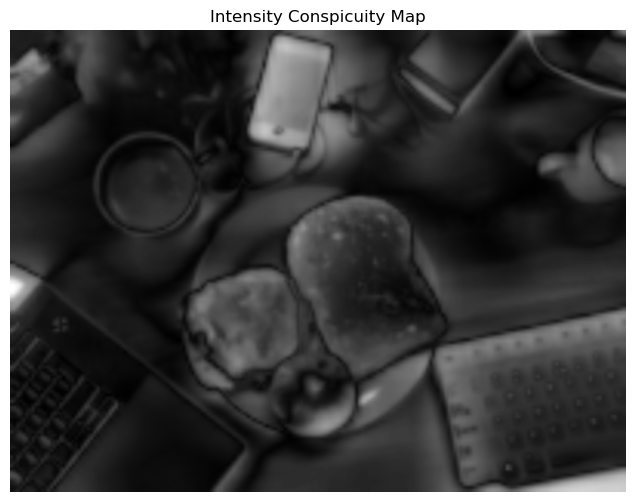

In [23]:
plt.figure(figsize=(8, 6))
plt.imshow(intensity_map_norm, cmap='gray')  # 'gray' colormap for better contrast
plt.title("Intensity Conspicuity Map")
plt.axis('off')  # Hide axes
plt.show()